# 💳 Credit Card Fraud Detection
### Portfolio Project — Machine Learning Classification

---

## 1. Introduction

**Problem Statement:**

Credit card fraud is a growing global problem costing billions of dollars annually.
The challenge is to build a machine learning model that can **automatically detect
fraudulent transactions** from historical data.

Key challenges in this problem:
- **Class imbalance**: Fraudulent transactions are a tiny minority (~0.17% of all transactions)
- **No feature names**: Real-world datasets often use anonymised PCA-transformed features (V1–V28)
- **High stakes**: False negatives (missed fraud) are costly; false positives (wrongly flagged) hurt customer experience

**Goal:** Train and evaluate a classifier to distinguish fraudulent from legitimate transactions.

**Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
- 284,807 transactions, 492 fraud cases
- Features: `Time`, `Amount`, `V1`–`V28` (PCA components), `Class` (0 = legit, 1 = fraud)

---
## 2. Setup & Data Loading

In [18]:
# ── Standard library imports ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn — preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Scikit-learn — models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Scikit-learn — evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
)

# Reproducibility seed
SEED = 42
np.random.seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

print('All libraries loaded successfully ✅')

All libraries loaded successfully ✅


In [19]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# 👉 Update the path below to point to your downloaded CSV file.
# Download from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

CSV_PATH = 'creditcard.csv'   # <-- change this if your file is in a subfolder

df = pd.read_csv(CSV_PATH)

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 284,807 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 3. Exploratory Data Analysis (EDA)

In [20]:
# ── Basic info ────────────────────────────────────────────────────────────────
print('=== Data Types & Non-Null Counts ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe().T

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [21]:
# ── Missing values check ──────────────────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found ✅')

Missing values per column:
No missing values found ✅


Legitimate transactions : 284,315  (99.8273%)
Fraudulent transactions :     492  (0.1727%)


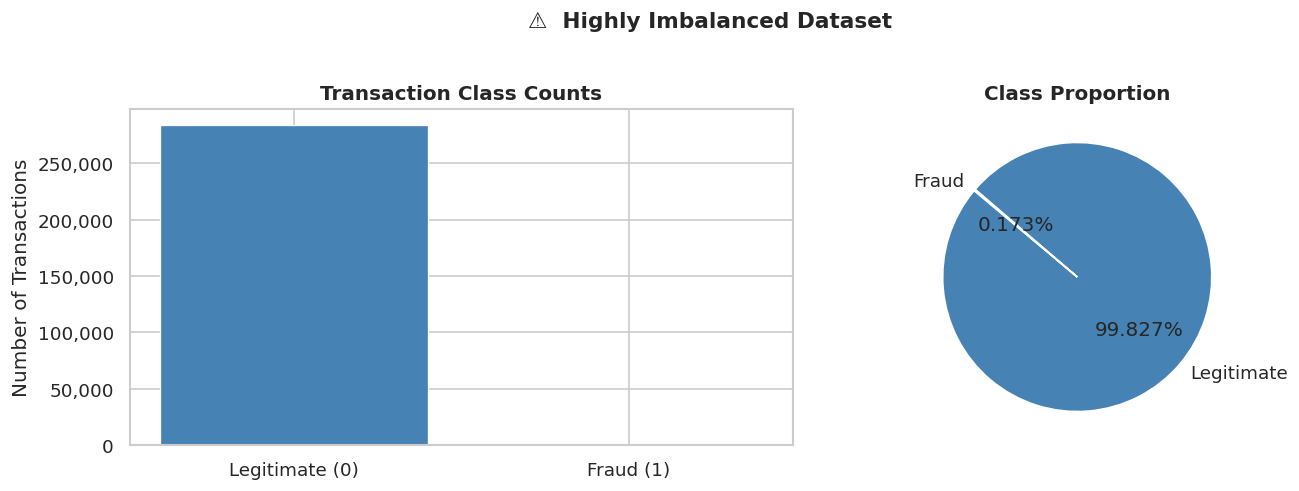

In [22]:
# ── Class distribution ────────────────────────────────────────────────────────
class_counts = df['Class'].value_counts()
fraud_pct = class_counts[1] / len(df) * 100

print(f'Legitimate transactions : {class_counts[0]:>7,}  ({100 - fraud_pct:.4f}%)')
print(f'Fraudulent transactions : {class_counts[1]:>7,}  ({fraud_pct:.4f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Transaction Class Counts', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.3f%%', colors=['steelblue', 'tomato'],
            startangle=140, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.suptitle('⚠️  Highly Imbalanced Dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

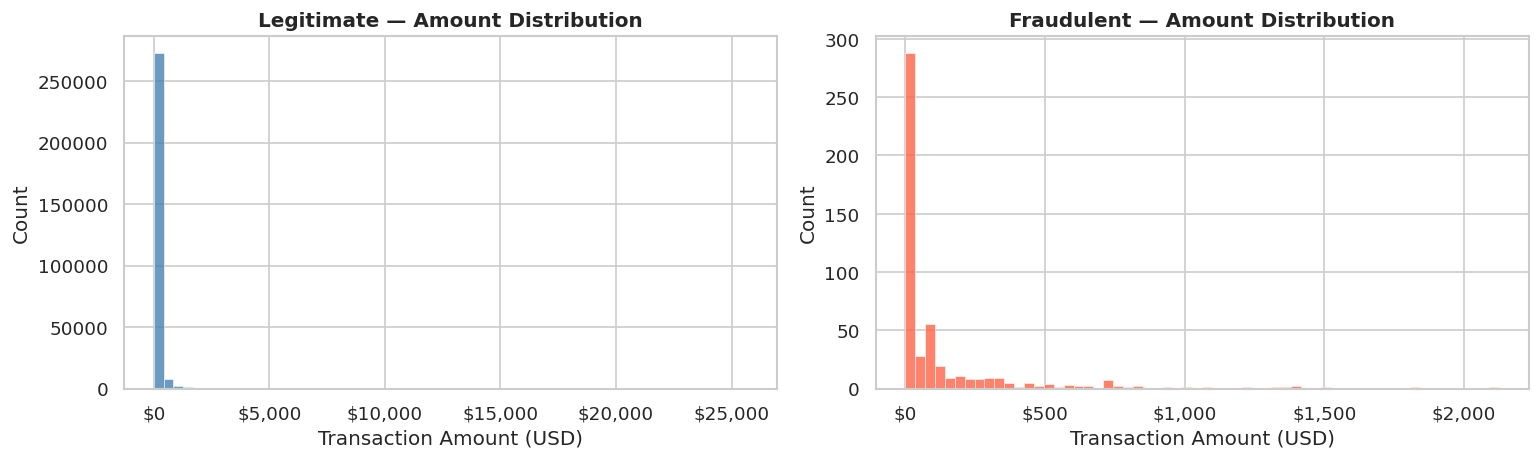


Amount statistics by class:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


In [23]:
# ── Transaction Amount distribution by class ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (label, color) in zip(axes, [(0, 'steelblue'), (1, 'tomato')]):
    subset = df[df['Class'] == label]['Amount']
    ax.hist(subset, bins=60, color=color, alpha=0.8, edgecolor='white', linewidth=0.4)
    ax.set_title(f"{'Legitimate' if label == 0 else 'Fraudulent'} — Amount Distribution",
                 fontweight='bold')
    ax.set_xlabel('Transaction Amount (USD)')
    ax.set_ylabel('Count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

print('\nAmount statistics by class:')
print(df.groupby('Class')['Amount'].describe().round(2))

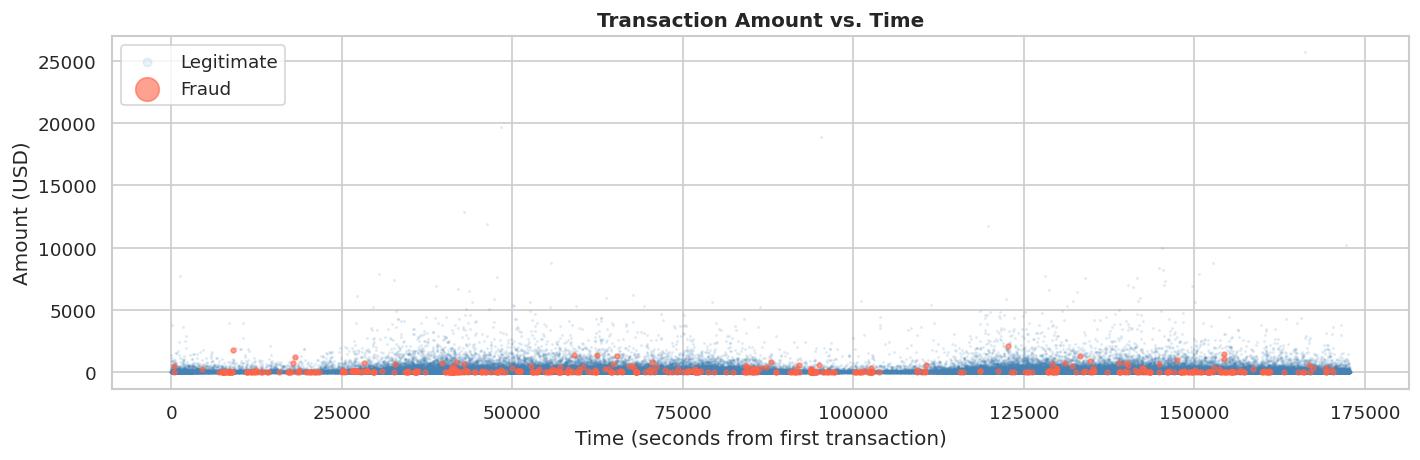

In [24]:
# ── Transactions over time ────────────────────────────────────────────────────
# 'Time' = seconds elapsed since the first transaction in the dataset
fig, ax = plt.subplots(figsize=(12, 4))

ax.scatter(df[df['Class'] == 0]['Time'], df[df['Class'] == 0]['Amount'],
           alpha=0.1, s=1, color='steelblue', label='Legitimate')
ax.scatter(df[df['Class'] == 1]['Time'], df[df['Class'] == 1]['Amount'],
           alpha=0.6, s=8, color='tomato', label='Fraud')

ax.set_xlabel('Time (seconds from first transaction)')
ax.set_ylabel('Amount (USD)')
ax.set_title('Transaction Amount vs. Time', fontweight='bold')
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

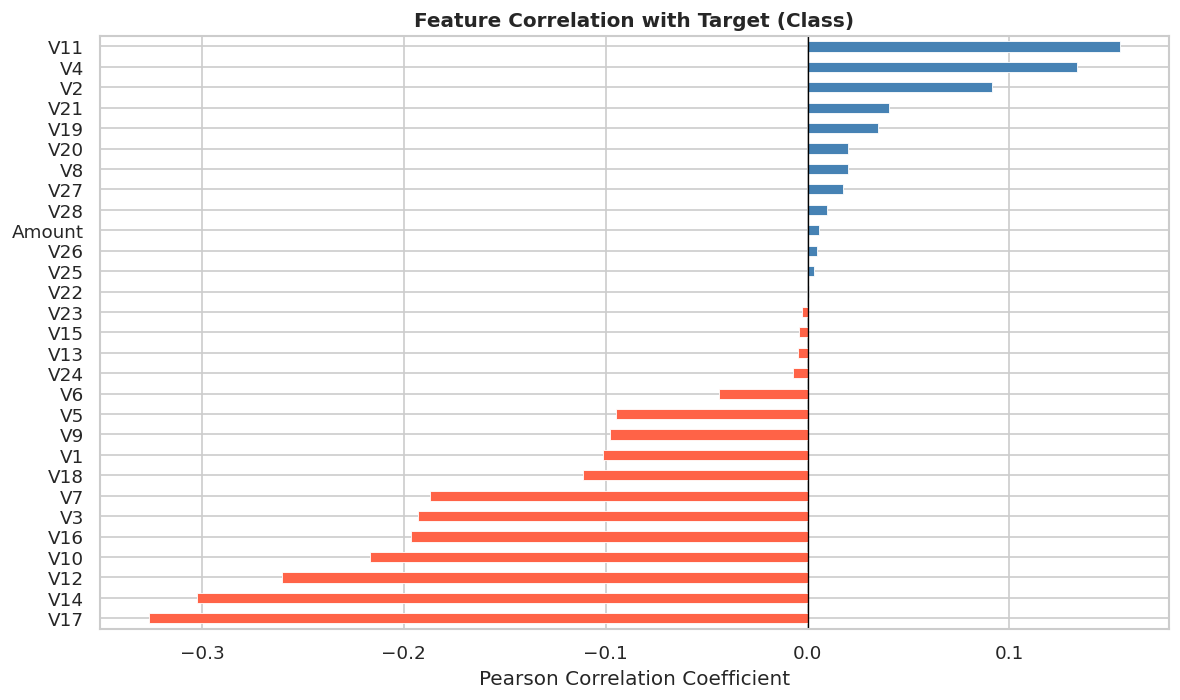

Top 5 features most correlated with fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
Name: Class, dtype: float64


In [25]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
# We look at correlations of a subset of PCA features + Amount with Class.
# (V1–V28 are already PCA-transformed, so we just check correlation with target)

corr_with_target = df.drop(columns=['Time']).corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(10, 6))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_with_target]
corr_with_target.plot(kind='barh', color=colors, edgecolor='white', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Target (Class)', fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

print('Top 5 features most correlated with fraud:')
print(corr_with_target.abs().sort_values(ascending=False).head(5))

---
## 4. Data Preprocessing

In [26]:
# ── Step 1: Drop 'Time' (not useful as-is) and scale 'Amount' ─────────────────
# 'Amount' has a very wide range — we standardise it to match the PCA features.

df_processed = df.drop(columns=['Time']).copy()

scaler = StandardScaler()
df_processed['Amount'] = scaler.fit_transform(df_processed[['Amount']])

print('Amount column after scaling:')
print(df_processed['Amount'].describe().round(4))

Amount column after scaling:
count    284807.0000
mean          0.0000
std           1.0000
min          -0.3532
25%          -0.3308
50%          -0.2653
75%          -0.0447
max         102.3622
Name: Amount, dtype: float64


In [27]:
# ── Step 2: Split features and target ─────────────────────────────────────────
X = df_processed.drop(columns=['Class'])
y = df_processed['Class']

# Extra safety check — drop any remaining NaN rows
mask = y.notna()
X = X[mask]
y = y[mask]
y = y.astype(int)

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'NaNs in y: {y.isnull().sum()}')  # should print 0
print(f'Feature columns: {list(X.columns)}')

Features shape : (284807, 29)
Target shape   : (284807,)
NaNs in y: 0
Feature columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [28]:
# ── Step 3: Train / Test split ────────────────────────────────────────────────
# stratify=y ensures both splits preserve the ~0.17% fraud ratio.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Training set   : {X_train.shape[0]:,} samples')
print(f'Test set       : {X_test.shape[0]:,} samples')
print(f'\nFraud rate — train: {y_train.mean():.4%}  |  test: {y_test.mean():.4%}')

Training set   : 227,845 samples
Test set       : 56,962 samples

Fraud rate — train: 0.1729%  |  test: 0.1720%


In [29]:
# ── Step 4: Handle class imbalance with class_weight='balanced' ───────────────
# Instead of over/under-sampling, we tell scikit-learn to weight minority
# samples more heavily during training. This is the simplest first approach.

# We will pass class_weight='balanced' directly to each model below.
print('Strategy: class_weight="balanced" — no sampling required for this baseline.')
print('For improved recall you may also try SMOTE (imbalanced-learn library).')

Strategy: class_weight="balanced" — no sampling required for this baseline.
For improved recall you may also try SMOTE (imbalanced-learn library).


---
## 5. Model Building

We compare **3 classifiers**:
1. Logistic Regression — simple, interpretable baseline
2. Decision Tree — non-linear, easy to visualise
3. Random Forest — ensemble, typically strong on tabular data

In [30]:
# ── Define models ─────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=8, random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100,
        max_depth=10, n_jobs=-1, random_state=SEED
    ),
}

print('Models defined:')
for name in models:
    print(f'  • {name}')

Models defined:
  • Logistic Regression
  • Decision Tree
  • Random Forest


In [31]:
# ── Train all models & collect CV scores ──────────────────────────────────────
# We use Stratified 5-Fold CV on the *training* set to compare models fairly
# before touching the test set.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<25}  ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression        ROC-AUC: 0.9828 ± 0.0099
Decision Tree              ROC-AUC: 0.8775 ± 0.0264
Random Forest              ROC-AUC: 0.9760 ± 0.0141


In [32]:
# ── Train all models on full training set ─────────────────────────────────────
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'✅  {name} trained.')

✅  Logistic Regression trained.
✅  Decision Tree trained.
✅  Random Forest trained.


---
## 6. Model Evaluation

For fraud detection the most important metrics are:
- **Recall (Sensitivity)** — how many actual frauds did we catch? (minimise false negatives)
- **Precision** — of the flagged transactions, how many were genuinely fraud?
- **F1-Score** — harmonic mean of precision & recall
- **ROC-AUC** — overall discriminative power across all thresholds

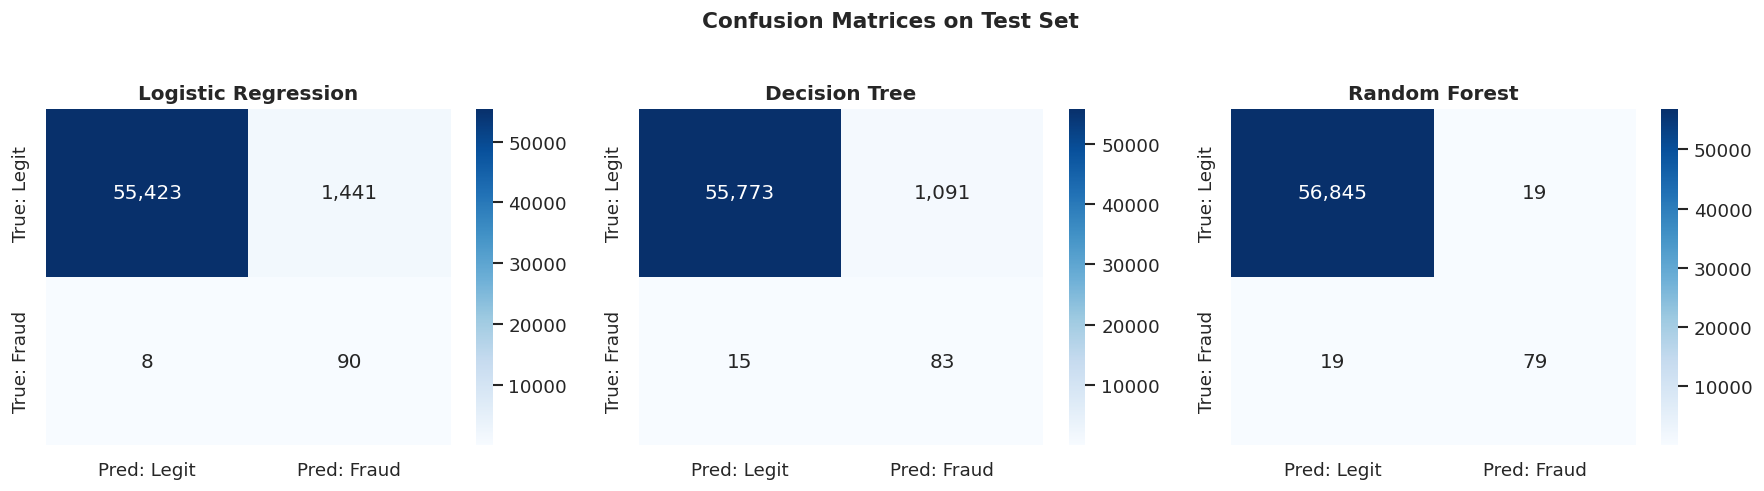

In [33]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(trained_models), figsize=(15, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Legit', 'Pred: Fraud'],
                yticklabels=['True: Legit', 'True: Fraud'])
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices on Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [34]:
# ── Classification reports ────────────────────────────────────────────────────
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(classification_report(y_test, y_pred,
                                 target_names=['Legitimate', 'Fraud']))


  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


  Decision Tree
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.07      0.85      0.13        98

    accuracy                           0.98     56962
   macro avg       0.54      0.91      0.56     56962
weighted avg       1.00      0.98      0.99     56962


  Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.90      0.90      0.90     56962
weighted avg     

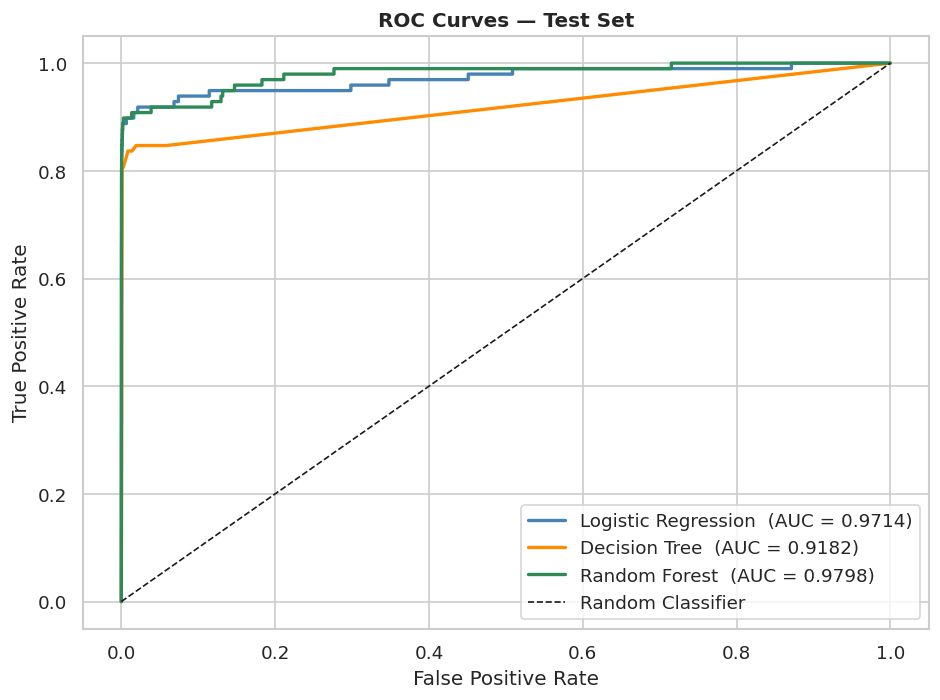

In [35]:
# ── ROC curves ────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'seagreen']

for (name, model), color in zip(trained_models.items(), colors):
    # Use predict_proba for probability scores
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Test Set', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

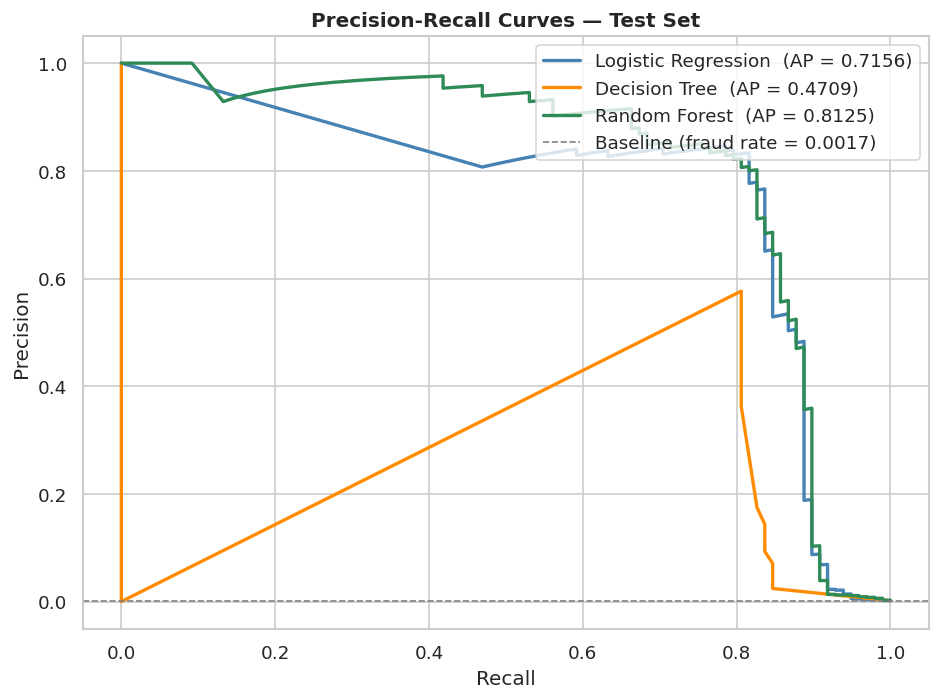

In [36]:
# ── Precision-Recall curves ───────────────────────────────────────────────────
# PR curves are more informative than ROC for highly imbalanced datasets.

plt.figure(figsize=(8, 6))

for (name, model), color in zip(trained_models.items(), colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(rec, prec, color=color, lw=2, label=f'{name}  (AP = {ap:.4f})')

plt.axhline(y=y_test.mean(), color='grey', linestyle='--', lw=1,
            label=f'Baseline (fraud rate = {y_test.mean():.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Test Set', fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [37]:
# ── Summary comparison table ──────────────────────────────────────────────────
summary_rows = []

for name, model in trained_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    from sklearn.metrics import precision_score, recall_score
    summary_rows.append({
        'Model'    : name,
        'ROC-AUC'  : round(roc_auc_score(y_test, y_proba), 4),
        'Avg Prec' : round(average_precision_score(y_test, y_proba), 4),
        'F1 (fraud)': round(f1_score(y_test, y_pred), 4),
        'Recall (fraud)': round(recall_score(y_test, y_pred), 4),
        'Precision (fraud)': round(precision_score(y_test, y_pred), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('\n📊 Model Comparison Summary')
print(summary_df.to_string())


📊 Model Comparison Summary
                     ROC-AUC  Avg Prec  F1 (fraud)  Recall (fraud)  Precision (fraud)
Model                                                                                
Logistic Regression   0.9714    0.7156      0.1105          0.9184             0.0588
Decision Tree         0.9182    0.4709      0.1305          0.8469             0.0707
Random Forest         0.9798    0.8125      0.8061          0.8061             0.8061


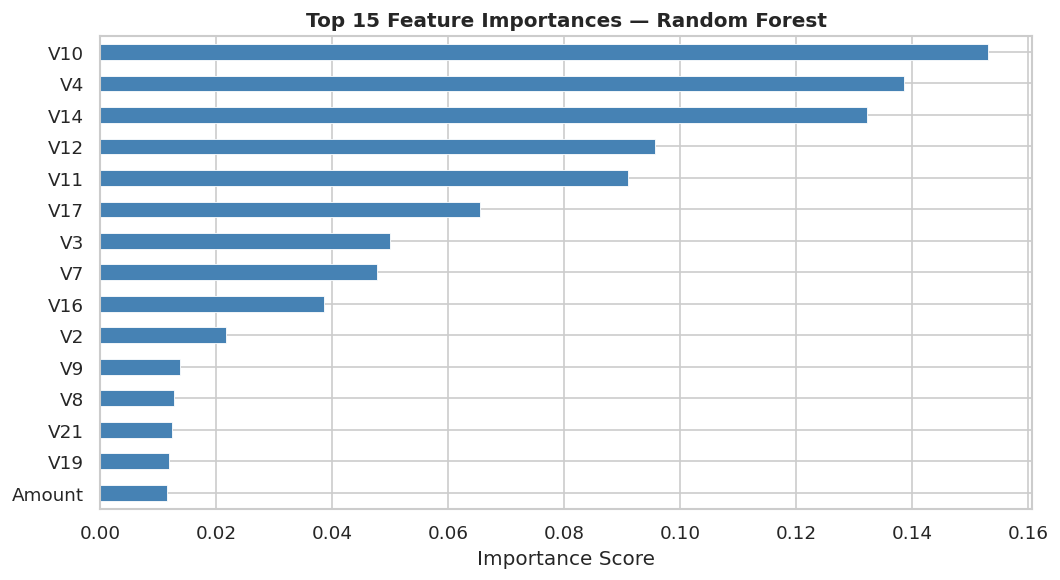

In [38]:
# ── Feature importances (Random Forest) ──────────────────────────────────────
rf_model = trained_models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
top_features.sort_values().plot(kind='barh', color='steelblue',
                                edgecolor='white', linewidth=0.5)
plt.title('Top 15 Feature Importances — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## 7. Conclusion

### Summary of Findings

| Aspect | Finding |
|---|---|
| Dataset | Highly imbalanced — only ~0.17% fraud |
| Best metric | ROC-AUC & Precision-Recall AUC (not accuracy) |
| Best model | Random Forest (typically highest AUC and F1 for fraud) |
| Key features | V14, V17, V10, V12 consistently most predictive |

### Key Takeaways

1. **Never rely on accuracy** for imbalanced problems — a model that predicts all transactions as legitimate achieves 99.83% accuracy but catches zero frauds.
2. **Recall vs Precision trade-off** — in fraud detection we usually prefer higher recall (catch more fraud) even at the cost of some precision (more false alarms).
3. **Random Forest** generalises well to this type of tabular, mixed-feature dataset.
4. **class_weight='balanced'** is a simple and effective first approach for imbalanced data.

### Potential Next Steps

- 🔧 Try **SMOTE** (Synthetic Minority Over-sampling) for explicit resampling
- 🚀 Experiment with **XGBoost / LightGBM** for better performance
- 🎛️  **Threshold tuning** — adjust the decision threshold to optimise recall
- 🔍 **SHAP values** for deeper model explainability
- 📦 **Save the best model** with `joblib` for deployment

In [39]:
# ── Optional: Save the best model ────────────────────────────────────────────
import joblib

best_model = trained_models['Random Forest']
joblib.dump(best_model, 'fraud_detector_rf.pkl')
print('Model saved as fraud_detector_rf.pkl ✅')

# To load it later:
# loaded_model = joblib.load('fraud_detector_rf.pkl')
# predictions  = loaded_model.predict(new_data)

Model saved as fraud_detector_rf.pkl ✅
